
# Klasifikasi Otomatis Tiket Helpdesk Teknologi Informasi Berbahasa Indonesia
## Menggunakan TF-IDF, Multilayer Perceptron, dan Long Short-Term Memory

### Tujuan
Sistem membaca kolom **Deskripsi** dan memprediksi salah satu dari lima kategori:

1. Akses
2. Jaringan
3. Keamanan
4. Perangkat Keras
5. Perangkat Lunak

Kolom **Subkategori tidak digunakan sebagai fitur model**. Kolom tersebut hanya digunakan untuk membuat pembagian data berbasis grup agar variasi dari subkategori yang sama tidak tersebar ke training dan testing.

### Skenario utama

| Kode | Model | Representasi teks | Tujuan |
|---|---|---|---|
| B0 | Logistic Regression | TF-IDF | Baseline machine learning |
| E1 | Multilayer Perceptron | TF-IDF | Menguji deep learning pada fitur TF-IDF |
| E2 | LSTM | Trainable Embedding | Menguji kemampuan mempelajari urutan kata |
| E3 | LSTM + Dropout 0,5 | Trainable Embedding | Menguji pengaruh regularisasi |

### Konfigurasi deep learning

- Optimizer: Adam
- Learning rate: 0,001
- Batch size: 32
- Maksimum epoch: 50
- Early stopping: patience 5
- Minimum improvement (`min_delta`): 0,001
- Loss: sparse categorical cross-entropy
- Metrik utama: Macro F1-score

Notebook juga memuat analisis **before–after augmentasi** dengan test set yang sama agar dampak penambahan data dapat dibandingkan secara lebih adil.


## 1. Import library dan konfigurasi

In [1]:

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Embedding,
    LSTM,
    TextVectorization,
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

KELAS = [
    "Akses",
    "Jaringan",
    "Keamanan",
    "Perangkat Keras",
    "Perangkat Lunak",
]

LABEL_TO_ID = {label: i for i, label in enumerate(KELAS)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
PATIENCE = 5
MIN_DELTA = 0.001

MAX_FEATURES_TFIDF = 5000
MAX_TOKENS = 5000
EMBEDDING_DIM = 64
LSTM_UNITS = 64

print("TensorFlow :", tf.__version__)
print("Pandas     :", pd.__version__)
print("NumPy      :", np.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))


TensorFlow : 2.20.0
Pandas     : 2.3.3
NumPy      : 2.0.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Menemukan file dataset

In [2]:

FILE_ASLI = "helpdesk_tickets_bahasa_indonesia.csv"
FILE_TAMBAHAN = "helpdesk_tickets_variasi_sintetis_1007.csv"

def cari_file(nama_file):
    lokasi = [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        Path("."),
        Path("/mnt/data"),
    ]

    for root in lokasi:
        if not root.exists():
            continue

        kandidat = root / nama_file
        if kandidat.exists():
            return kandidat

        hasil = list(root.rglob(nama_file))
        if hasil:
            return hasil[0]

    raise FileNotFoundError(
        f"{nama_file} tidak ditemukan. "
        "Tambahkan kedua CSV ke Kaggle Notebook sebelum menjalankan notebook."
    )

path_asli = cari_file(FILE_ASLI)
path_tambahan = cari_file(FILE_TAMBAHAN)

print("Dataset awal    :", path_asli)
print("Data tambahan   :", path_tambahan)


Dataset awal    : /kaggle/input/datasets/masrezah/ticket-it/helpdesk_tickets_bahasa_indonesia.csv
Data tambahan   : /kaggle/input/datasets/masrezah/ticket-it/helpdesk_tickets_variasi_sintetis_1007.csv



## 3. Mengambil data unik dari dataset awal

File hasil terjemahan awal berisi banyak pengulangan. File dibaca per bagian menggunakan `chunksize` agar hemat memori, kemudian hanya deskripsi unik yang dipertahankan.


In [3]:

KOLOM = ["Kategori", "Subkategori", "Deskripsi"]

def rapikan_kolom(df):
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]

    kolom_hilang = [col for col in KOLOM if col not in df.columns]
    if kolom_hilang:
        raise ValueError(f"Kolom tidak ditemukan: {kolom_hilang}")

    return df[KOLOM]

def baca_data_awal_unik(path, chunksize=100_000):
    bagian_unik = []

    for chunk in pd.read_csv(
        path,
        usecols=KOLOM,
        chunksize=chunksize,
        encoding="utf-8-sig",
    ):
        chunk = rapikan_kolom(chunk)
        chunk = chunk.dropna(subset=KOLOM).copy()

        for col in KOLOM:
            chunk[col] = chunk[col].astype(str).str.strip()

        bagian_unik.append(
            chunk.drop_duplicates(subset=["Deskripsi"])
        )

    hasil = pd.concat(bagian_unik, ignore_index=True)

    hasil = (
        hasil.drop_duplicates(subset=["Deskripsi"])
        .reset_index(drop=True)
    )

    return hasil

df_asli = baca_data_awal_unik(path_asli)
df_asli["Asal_Data"] = "Dataset awal"

print("Jumlah deskripsi unik dataset awal:", len(df_asli))
display(df_asli.head())


Jumlah deskripsi unik dataset awal: 493


,Kategori,Subkategori,Deskripsi,Asal_Data
0,Akses,Akses ditolak oleh kebijakan auditor,Pengguna melaporkan akses ditolak oleh kebijak...,Dataset awal
1,Keamanan,Injeksi DLL mencurigakan,Pengguna melaporkan injeksi dll mencurigakan. ...,Dataset awal
2,Keamanan,Peringatan SOC mencurigakan,Pengguna melaporkan peringatan soc mencurigaka...,Dataset awal
3,Perangkat Lunak,Aplikasi macet,Pengguna melaporkan aplikasi macet. Diperlukan...,Dataset awal
4,Akses,Kegagalan pencatatan akses,Pengguna melaporkan kegagalan pencatatan akses...,Dataset awal


## 4. Membaca 1.007 variasi sintetis tambahan

In [4]:

df_tambahan = pd.read_csv(
    path_tambahan,
    encoding="utf-8-sig",
)

df_tambahan = rapikan_kolom(df_tambahan)
df_tambahan = df_tambahan.dropna(subset=KOLOM).copy()

for col in KOLOM:
    df_tambahan[col] = (
        df_tambahan[col]
        .astype(str)
        .str.strip()
    )

df_tambahan = (
    df_tambahan.drop_duplicates(subset=["Deskripsi"])
    .reset_index(drop=True)
)

df_tambahan["Asal_Data"] = "Variasi sintetis tambahan"

print("Jumlah variasi sintetis unik:", len(df_tambahan))
display(df_tambahan.head())


Jumlah variasi sintetis unik: 1007


,Kategori,Subkategori,Deskripsi,Asal_Data
0,Akses,Akses ditolak oleh API,"Saat mencoba menggunakan layanan kerja, penggu...",Variasi sintetis tambahan
1,Akses,Akses ditolak oleh akses bersyarat,Tiket dibuat setelah pengguna menemukan Akses ...,Variasi sintetis tambahan
2,Akses,Akses ditolak oleh aplikasi,Masalah Akses ditolak oleh aplikasi muncul pad...,Variasi sintetis tambahan
3,Akses,Akses ditolak oleh basis data,Permintaan dukungan dibuat karena Akses ditola...,Variasi sintetis tambahan
4,Akses,Akses ditolak oleh firewall,"Pada saat autentikasi, pengguna mengalami Akse...",Variasi sintetis tambahan



## 5. Cleaning data

Cleaning dibuat ringan agar informasi teknis pada tiket tidak banyak hilang.

Langkah yang dilakukan:

- mengubah teks menjadi huruf kecil;
- mengganti URL menjadi token `url`;
- mengganti alamat email menjadi token `email`;
- menghapus tanda baca;
- merapikan spasi;
- mempertahankan angka karena angka dapat bermakna pada kasus TI.


In [5]:

def bersihkan_teks(teks):
    teks = str(teks).lower()

    teks = re.sub(r"https?://\S+|www\.\S+", " url ", teks)
    teks = re.sub(r"\S+@\S+", " email ", teks)

    # Angka dipertahankan. Hanya tanda baca yang dibersihkan.
    teks = re.sub(r"[^\w\s]", " ", teks, flags=re.UNICODE)
    teks = re.sub(r"\s+", " ", teks).strip()

    return teks

df = pd.concat(
    [df_asli, df_tambahan],
    ignore_index=True,
)

df["Kategori"] = df["Kategori"].str.strip()

df["Subkategori"] = (
    df["Subkategori"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["Deskripsi_Bersih"] = (
    df["Deskripsi"]
    .apply(bersihkan_teks)
)

df = df[
    df["Deskripsi_Bersih"].str.len() > 0
].copy()

# Satu teks tidak boleh memiliki lebih dari satu label.
konflik_label = (
    df.groupby("Deskripsi_Bersih")["Kategori"]
    .nunique()
)

konflik_label = konflik_label[
    konflik_label > 1
]

if len(konflik_label) > 0:
    raise ValueError(
        f"Ditemukan {len(konflik_label)} deskripsi dengan label kategori berbeda."
    )

df = (
    df.drop_duplicates(subset=["Deskripsi_Bersih"])
    .reset_index(drop=True)
)

df = (
    df[df["Kategori"].isin(KELAS)]
    .reset_index(drop=True)
)

print("Jumlah data setelah cleaning :", len(df))
print("Deskripsi unik               :", df["Deskripsi_Bersih"].nunique())
print("Missing value                :", int(df.isna().sum().sum()))


Jumlah data setelah cleaning : 1500
Deskripsi unik               : 1500
Missing value                : 0


## 6. Before–after augmentasi dataset

In [6]:

df_awal_bersih = (
    df[df["Asal_Data"] == "Dataset awal"]
    .copy()
    .reset_index(drop=True)
)

df_tambahan_bersih = (
    df[df["Asal_Data"] == "Variasi sintetis tambahan"]
    .copy()
    .reset_index(drop=True)
)

dist_awal = (
    df_awal_bersih["Kategori"]
    .value_counts()
    .reindex(KELAS)
)

dist_tambahan = (
    df_tambahan_bersih["Kategori"]
    .value_counts()
    .reindex(KELAS)
)

dist_final = (
    df["Kategori"]
    .value_counts()
    .reindex(KELAS)
)

tabel_before_after = pd.DataFrame({
    "Sebelum Augmentasi": dist_awal,
    "Tambahan Sintetis": dist_tambahan,
    "Setelah Augmentasi": dist_final,
})

tabel_before_after.loc["Total"] = (
    tabel_before_after.sum(axis=0)
)

display(tabel_before_after)

assert len(df_awal_bersih) == 493, (
    f"Data awal seharusnya 493, ditemukan {len(df_awal_bersih)}."
)

assert len(df_tambahan_bersih) == 1007, (
    f"Data tambahan seharusnya 1.007, ditemukan {len(df_tambahan_bersih)}."
)

assert len(df) == 1500, (
    f"Dataset final seharusnya 1.500, ditemukan {len(df)}."
)

assert df["Deskripsi_Bersih"].nunique() == 1500, (
    "Masih terdapat deskripsi duplikat setelah cleaning."
)

assert (dist_final == 300).all(), (
    "Distribusi dataset final belum 300 data per kategori."
)

assert (
    df.groupby("Subkategori")["Kategori"]
    .nunique()
    .max() == 1
), "Ada Subkategori yang terhubung dengan lebih dari satu Kategori."

print("Validasi dataset selesai: 1.500 data unik dan 300 data per kelas.")


,Sebelum Augmentasi,Tambahan Sintetis,Setelah Augmentasi
Kategori,,,
Akses,100,200,300
Jaringan,98,202,300
Keamanan,99,201,300
Perangkat Keras,97,203,300
Perangkat Lunak,99,201,300
Total,493,1007,1500


Validasi dataset selesai: 1.500 data unik dan 300 data per kelas.


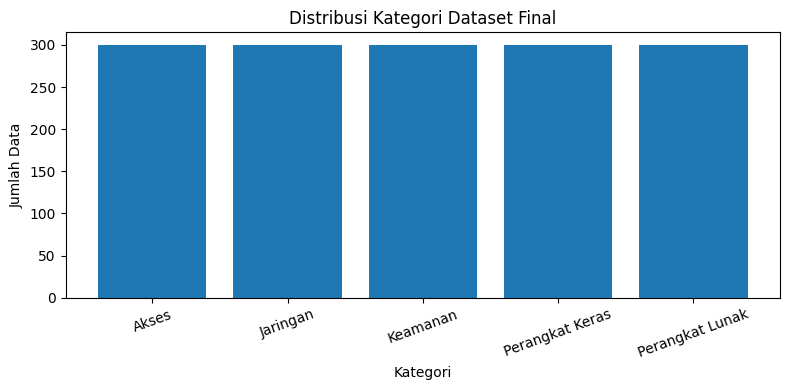

In [7]:

plt.figure(figsize=(8, 4))
plt.bar(
    dist_final.index,
    dist_final.values,
)
plt.title("Distribusi Kategori Dataset Final")
plt.xlabel("Kategori")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [8]:

display(
    df[
        [
            "Kategori",
            "Subkategori",
            "Deskripsi",
            "Deskripsi_Bersih",
            "Asal_Data",
        ]
    ].sample(
        8,
        random_state=SEED,
    )
)


,Kategori,Subkategori,Deskripsi,Deskripsi_Bersih,Asal_Data
1116,Perangkat Keras,Kapasitor motherboard rusak,Pengguna mengalami Kapasitor motherboard rusak...,pengguna mengalami kapasitor motherboard rusak...,Variasi sintetis tambahan
1368,Perangkat Lunak,Kesalahan compiler,"Ketika aplikasi dijalankan, terjadi Kesalahan ...",ketika aplikasi dijalankan terjadi kesalahan c...,Variasi sintetis tambahan
422,Perangkat Keras,Masalah klik ganda mouse,Pengguna melaporkan masalah klik ganda mouse. ...,pengguna melaporkan masalah klik ganda mouse d...,Dataset awal
413,Perangkat Keras,CPU terlalu panas,Pengguna melaporkan cpu terlalu panas. Diperlu...,pengguna melaporkan cpu terlalu panas diperluk...,Dataset awal
451,Jaringan,Jaringan: pelanggaran kepatuhan,Pengguna melaporkan jaringan: pelanggaran kepa...,pengguna melaporkan jaringan pelanggaran kepat...,Dataset awal
861,Jaringan,Kegagalan DHCP,"Selama bekerja, pengguna menemui Kegagalan DHC...",selama bekerja pengguna menemui kegagalan dhcp...,Variasi sintetis tambahan
1063,Keamanan,Percobaan login brute force,Pengguna melaporkan adanya Percobaan login bru...,pengguna melaporkan adanya percobaan login bru...,Variasi sintetis tambahan
741,Jaringan,Jaringan: kesalahan subnet mask,"Selama bekerja, pengguna menemui Jaringan: kes...",selama bekerja pengguna menemui jaringan kesal...,Variasi sintetis tambahan



## 7. Pembagian data 70% / 15% / 15% berbasis Subkategori

Variasi kalimat dari `Subkategori` yang sama tidak boleh berada pada split yang berbeda. Oleh karena itu, pembagian dilakukan berdasarkan grup `Subkategori`.

Target final:

- Training: 1.050 data (70%)
- Validation: 225 data (15%)
- Testing: 225 data (15%)

Setiap kategori tetap memiliki:

- 210 data training
- 45 data validation
- 45 data testing


In [9]:

def pilih_group_dengan_target(df_kategori, target, seed):
    ukuran_group = (
        df_kategori
        .groupby("Subkategori")
        .size()
    )

    pasangan = list(ukuran_group.items())

    rng = np.random.default_rng(seed)
    rng.shuffle(pasangan)

    # Mencari kombinasi ukuran grup yang tepat mencapai target.
    kombinasi = {0: []}

    for subkategori, ukuran in pasangan:
        kondisi_saat_ini = list(kombinasi.items())

        for total, group_terpilih in kondisi_saat_ini:
            total_baru = total + int(ukuran)

            if (
                total_baru <= target
                and total_baru not in kombinasi
            ):
                kombinasi[total_baru] = (
                    group_terpilih + [subkategori]
                )

        if target in kombinasi:
            return set(kombinasi[target])

    raise ValueError(
        f"Tidak ditemukan kombinasi Subkategori untuk target {target}."
    )


def grouped_stratified_split(df, seed=42):
    idx_train = []
    idx_val = []
    idx_test = []

    for i, kategori in enumerate(KELAS):
        data_kategori = df[
            df["Kategori"] == kategori
        ]

        group_test = pilih_group_dengan_target(
            data_kategori,
            target=45,
            seed=seed + (i * 100),
        )

        sisa = data_kategori[
            ~data_kategori["Subkategori"].isin(group_test)
        ]

        group_val = pilih_group_dengan_target(
            sisa,
            target=45,
            seed=seed + (i * 100) + 1,
        )

        group_train = (
            set(sisa["Subkategori"].unique())
            - group_val
        )

        idx_test.extend(
            data_kategori[
                data_kategori["Subkategori"].isin(group_test)
            ].index.tolist()
        )

        idx_val.extend(
            data_kategori[
                data_kategori["Subkategori"].isin(group_val)
            ].index.tolist()
        )

        idx_train.extend(
            data_kategori[
                data_kategori["Subkategori"].isin(group_train)
            ].index.tolist()
        )

    return idx_train, idx_val, idx_test


idx_train, idx_val, idx_test = grouped_stratified_split(
    df,
    seed=SEED,
)

train_df = (
    df.loc[idx_train]
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

val_df = (
    df.loc[idx_val]
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

test_df = (
    df.loc[idx_test]
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f"Training   : {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validation : {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Testing    : {len(test_df)} ({len(test_df)/len(df):.1%})")


Training   : 1050 (70.0%)
Validation : 225 (15.0%)
Testing    : 225 (15.0%)


## 8. Validasi split dan pengecekan data leakage

In [10]:

group_train = set(train_df["Subkategori"])
group_val = set(val_df["Subkategori"])
group_test = set(test_df["Subkategori"])

overlap_train_val = group_train & group_val
overlap_train_test = group_train & group_test
overlap_val_test = group_val & group_test

teks_train = set(train_df["Deskripsi_Bersih"])
teks_val = set(val_df["Deskripsi_Bersih"])
teks_test = set(test_df["Deskripsi_Bersih"])

print("Overlap Subkategori")
print("Train - Validation :", len(overlap_train_val))
print("Train - Test       :", len(overlap_train_test))
print("Validation - Test  :", len(overlap_val_test))

print("\nOverlap Deskripsi Bersih")
print("Train - Validation :", len(teks_train & teks_val))
print("Train - Test       :", len(teks_train & teks_test))
print("Validation - Test  :", len(teks_val & teks_test))

assert len(train_df) == 1050
assert len(val_df) == 225
assert len(test_df) == 225

assert len(overlap_train_val) == 0
assert len(overlap_train_test) == 0
assert len(overlap_val_test) == 0

assert len(teks_train & teks_val) == 0
assert len(teks_train & teks_test) == 0
assert len(teks_val & teks_test) == 0

print("\nSplit valid: tidak ada kebocoran Subkategori maupun teks identik.")


Overlap Subkategori
Train - Validation : 0
Train - Test       : 0
Validation - Test  : 0

Overlap Deskripsi Bersih
Train - Validation : 0
Train - Test       : 0
Validation - Test  : 0

Split valid: tidak ada kebocoran Subkategori maupun teks identik.


In [11]:

def distribusi_split(data, nama):
    return (
        data["Kategori"]
        .value_counts()
        .reindex(KELAS)
        .rename(nama)
    )

tabel_split = pd.concat(
    [
        distribusi_split(train_df, "Train"),
        distribusi_split(val_df, "Validation"),
        distribusi_split(test_df, "Test"),
    ],
    axis=1,
)

display(tabel_split)

assert (tabel_split["Train"] == 210).all()
assert (tabel_split["Validation"] == 45).all()
assert (tabel_split["Test"] == 45).all()


,Train,Validation,Test
Kategori,,,
Akses,210,45,45
Jaringan,210,45,45
Keamanan,210,45,45
Perangkat Keras,210,45,45
Perangkat Lunak,210,45,45


In [12]:

asal_split = pd.concat(
    [
        train_df.assign(Split="Train"),
        val_df.assign(Split="Validation"),
        test_df.assign(Split="Test"),
    ],
    ignore_index=True,
)

display(
    pd.crosstab(
        asal_split["Split"],
        asal_split["Asal_Data"],
    )
)


Asal_Data,Dataset awal,Variasi sintetis tambahan
Split,,
Test,75,150
Train,343,707
Validation,75,150


## 9. Menyimpan dataset final beserta split

In [13]:

OUTPUT_DIR = (
    Path("/kaggle/working/final_project_outputs")
    if Path("/kaggle/working").exists()
    else Path("./final_project_outputs")
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

df_split = pd.concat(
    [
        train_df.assign(Split="Train"),
        val_df.assign(Split="Validation"),
        test_df.assign(Split="Test"),
    ],
    ignore_index=True,
)

FILE_CLEAN = (
    OUTPUT_DIR
    / "helpdesk_tickets_indonesia_clean_1500_dengan_split.csv"
)

FILE_RINGKASAN_DATA = (
    OUTPUT_DIR
    / "ringkasan_before_after_dataset.csv"
)

df_split.to_csv(
    FILE_CLEAN,
    index=False,
    encoding="utf-8-sig",
)

tabel_before_after.to_csv(
    FILE_RINGKASAN_DATA,
    encoding="utf-8-sig",
)

print("Dataset final :", FILE_CLEAN)
print("Ringkasan     :", FILE_RINGKASAN_DATA)


Dataset final : /kaggle/working/final_project_outputs/helpdesk_tickets_indonesia_clean_1500_dengan_split.csv
Ringkasan     : /kaggle/working/final_project_outputs/ringkasan_before_after_dataset.csv


## 10. Menyiapkan fitur dan label

In [14]:

X_train = train_df["Deskripsi_Bersih"].copy()
X_val = val_df["Deskripsi_Bersih"].copy()
X_test = test_df["Deskripsi_Bersih"].copy()

y_train = (
    train_df["Kategori"]
    .map(LABEL_TO_ID)
    .astype(int)
)

y_val = (
    val_df["Kategori"]
    .map(LABEL_TO_ID)
    .astype(int)
)

y_test = (
    test_df["Kategori"]
    .map(LABEL_TO_ID)
    .astype(int)
)

print("Input  : Deskripsi_Bersih")
print("Target : Kategori")
print("\nMapping label:")

for label, idx in LABEL_TO_ID.items():
    print(f"{idx} -> {label}")


# Common test set untuk analisis before-after augmentasi.
# Semua Subkategori pada set ini tidak pernah masuk ke training.
common_test_df = (
    df_awal_bersih[
        df_awal_bersih["Subkategori"].isin(group_test)
    ]
    .reset_index(drop=True)
)

y_common_test = (
    common_test_df["Kategori"]
    .map(LABEL_TO_ID)
    .astype(int)
)

assert len(common_test_df) == 75
assert (
    common_test_df["Kategori"]
    .value_counts()
    .reindex(KELAS)
    .eq(15)
    .all()
)


Input  : Deskripsi_Bersih
Target : Kategori

Mapping label:
0 -> Akses
1 -> Jaringan
2 -> Keamanan
3 -> Perangkat Keras
4 -> Perangkat Lunak


## 11. Fungsi evaluasi dan analisis training

In [15]:

hasil_model = []
prediksi_model = {}
history_model = {}
ringkasan_training = []

def hitung_metrik(y_true, y_pred):
    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )
    )

    return {
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
    }


def evaluasi_model(nama_model, y_true, y_pred):
    metrik = hitung_metrik(
        y_true,
        y_pred,
    )

    hasil_model.append({
        "Model": nama_model,
        **metrik,
    })

    prediksi_model[nama_model] = np.asarray(y_pred)

    print(nama_model)
    print("-" * len(nama_model))

    for nama, nilai in metrik.items():
        print(f"{nama:16s}: {nilai:.4f}")


def buat_early_stopping():
    return EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        restore_best_weights=True,
        verbose=1,
    )


def simpan_ringkasan_history(nama_model, history):
    hist = pd.DataFrame(history.history)

    best_idx = int(
        hist["val_loss"].idxmin()
    )

    ringkasan_training.append({
        "Model": nama_model,
        "Epoch Dijalankan": len(hist),
        "Epoch Terbaik": best_idx + 1,
        "Train Accuracy @ Best": hist.loc[best_idx, "accuracy"],
        "Validation Accuracy @ Best": hist.loc[best_idx, "val_accuracy"],
        "Minimum Validation Loss": hist.loc[best_idx, "val_loss"],
        "Gap Accuracy @ Best": (
            hist.loc[best_idx, "accuracy"]
            - hist.loc[best_idx, "val_accuracy"]
        ),
    })


def tampilkan_history(history, nama_model):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(
        hist.index + 1,
        hist["loss"],
        marker="o",
        label="Training loss",
    )
    plt.plot(
        hist.index + 1,
        hist["val_loss"],
        marker="o",
        label="Validation loss",
    )
    plt.title(f"Loss - {nama_model}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(
        hist.index + 1,
        hist["accuracy"],
        marker="o",
        label="Training accuracy",
    )
    plt.plot(
        hist.index + 1,
        hist["val_accuracy"],
        marker="o",
        label="Validation accuracy",
    )
    plt.title(f"Accuracy - {nama_model}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


def tampilkan_confusion_matrix(nama_model):
    y_pred = prediksi_model[nama_model]

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=range(len(KELAS)),
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=KELAS,
    )

    disp.plot(
        values_format="d",
        colorbar=False,
    )

    plt.title(
        f"Confusion Matrix - {nama_model}"
    )
    plt.xticks(
        rotation=30,
        ha="right",
    )
    plt.tight_layout()
    plt.show()



## 12. B0 — Logistic Regression + TF-IDF

TF-IDF dan Logistic Regression digabung dalam satu `Pipeline`. Dengan demikian, TF-IDF hanya mempelajari vocabulary dan IDF ketika pipeline di-fit pada training set.


In [16]:

pipeline_b0 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=MAX_FEATURES_TFIDF,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            solver="lbfgs",
            max_iter=1000,
            random_state=SEED,
        ),
    ),
])

pipeline_b0.fit(
    X_train,
    y_train,
)

pred_b0 = pipeline_b0.predict(
    X_test
)

evaluasi_model(
    "B0 - Logistic Regression",
    y_test,
    pred_b0,
)


pred_b0_after_common = pipeline_b0.predict(
    common_test_df["Deskripsi_Bersih"]
)


B0 - Logistic Regression
------------------------
Accuracy        : 0.9422
Macro Precision : 0.9435
Macro Recall    : 0.9422
Macro F1        : 0.9423


                 precision    recall  f1-score   support

          Akses       0.98      0.98      0.98        45
       Jaringan       0.89      0.89      0.89        45
       Keamanan       0.91      0.96      0.93        45
Perangkat Keras       0.94      0.98      0.96        45
Perangkat Lunak       1.00      0.91      0.95        45

       accuracy                           0.94       225
      macro avg       0.94      0.94      0.94       225
   weighted avg       0.94      0.94      0.94       225



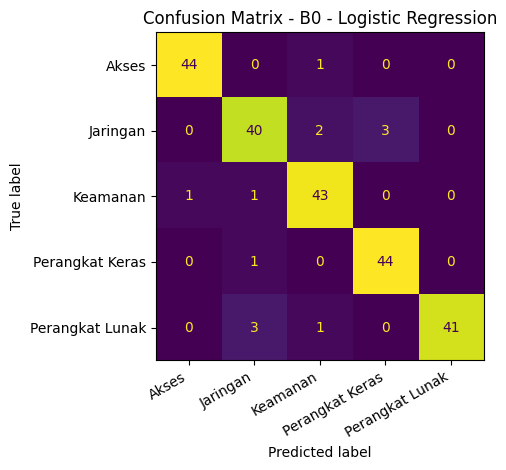

In [17]:

print(
    classification_report(
        y_test,
        pred_b0,
        labels=range(len(KELAS)),
        target_names=KELAS,
        zero_division=0,
    )
)

tampilkan_confusion_matrix(
    "B0 - Logistic Regression"
)



## 13. Menyiapkan TF-IDF untuk E1

Vectorizer dari baseline digunakan kembali agar B0 dan E1 menggunakan representasi TF-IDF yang sama.


In [18]:

tfidf = pipeline_b0.named_steps["tfidf"]

X_train_tfidf = tfidf.transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

X_train_mlp = X_train_tfidf.toarray().astype("float32")
X_val_mlp = X_val_tfidf.toarray().astype("float32")
X_test_mlp = X_test_tfidf.toarray().astype("float32")

print("Jumlah fitur TF-IDF :", len(tfidf.get_feature_names_out()))
print("Train               :", X_train_mlp.shape)
print("Validation          :", X_val_mlp.shape)
print("Test                :", X_test_mlp.shape)


Jumlah fitur TF-IDF : 1800
Train               : (1050, 1800)
Validation          : (225, 1800)
Test                : (225, 1800)


In [19]:

def buat_model_mlp(input_dim, nama_model):
    model = tf.keras.Sequential(
        [
            Input(
                shape=(input_dim,),
                name="tfidf",
            ),
            Dense(
                128,
                activation="relu",
            ),
            Dense(
                64,
                activation="relu",
            ),
            Dense(
                len(KELAS),
                activation="softmax",
            ),
        ],
        name=nama_model,
    )

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


## 14. E1 — Multilayer Perceptron + TF-IDF

In [20]:

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

model_e1 = buat_model_mlp(
    input_dim=X_train_mlp.shape[1],
    nama_model="E1_MLP_TFIDF",
)

model_e1.summary()


I0000 00:00:1786885752.155377      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786885752.158363      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "E1_MLP_TFIDF"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       230,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,109 (934.02 KB)

 Trainable params: 239,109 (934.02 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:

history_e1 = model_e1.fit(
    X_train_mlp,
    y_train.to_numpy(),
    validation_data=(
        X_val_mlp,
        y_val.to_numpy(),
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        buat_early_stopping()
    ],
    verbose=1,
)

history_model["E1 - MLP"] = history_e1

simpan_ringkasan_history(
    "E1 - MLP",
    history_e1,
)

pred_e1 = np.argmax(
    model_e1.predict(
        X_test_mlp,
        verbose=0,
    ),
    axis=1,
)

evaluasi_model(
    "E1 - MLP",
    y_test,
    pred_e1,
)


X_common_after_tfidf = (
    tfidf
    .transform(common_test_df["Deskripsi_Bersih"])
    .toarray()
    .astype("float32")
)

pred_e1_after_common = np.argmax(
    model_e1.predict(
        X_common_after_tfidf,
        verbose=0,
    ),
    axis=1,
)


Epoch 1/50


2026-08-16 13:09:13.656448: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7667 - loss: 1.4738 - val_accuracy: 0.9156 - val_loss: 1.1564
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.6527 - val_accuracy: 0.9511 - val_loss: 0.2876
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9981 - loss: 0.1224 - val_accuracy: 0.9556 - val_loss: 0.1731
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9981 - loss: 0.0431 - val_accuracy: 0.9644 - val_loss: 0.1526
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9981 - loss: 0.0213 - val_accuracy: 0.9644 - val_loss: 0.1433
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0128 - val_accuracy: 0.9689 - val_loss: 0.1406
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0087 - val_accuracy: 0.9689 - val_loss: 0.1392
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.9689 - val_loss: 0.1388
Ep

2026-08-16 13:09:20.676937: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


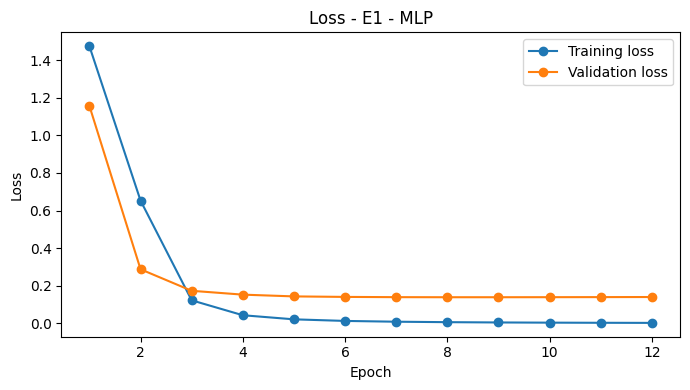

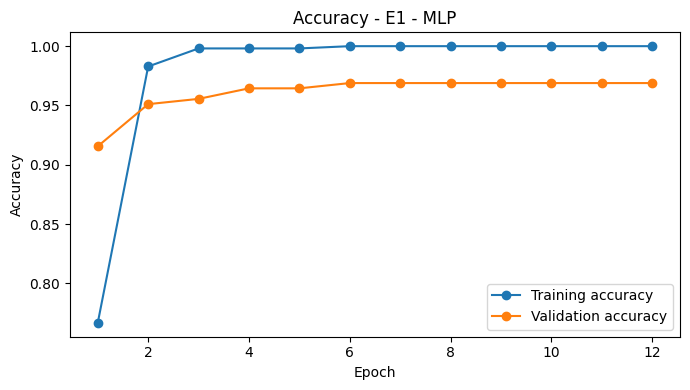

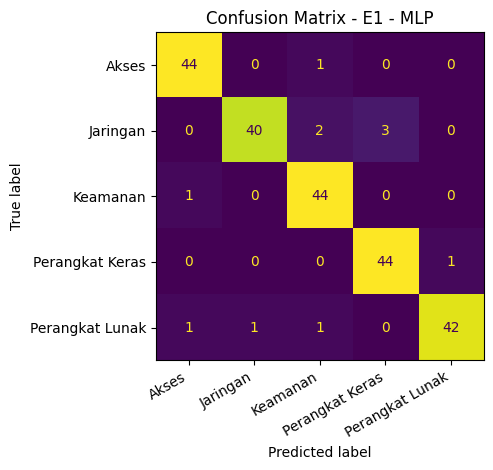

In [22]:

tampilkan_history(
    history_e1,
    "E1 - MLP",
)

tampilkan_confusion_matrix(
    "E1 - MLP"
)



## 15. Menyiapkan sequence untuk LSTM

Daftar kata yang digunakan model hanya diambil dari data training. Setelah itu, setiap teks diubah menjadi urutan angka agar bisa diproses oleh model. Panjang teks juga diseragamkan berdasarkan sebagian besar panjang kalimat yang ada pada data training.


In [23]:

panjang_teks = (
    X_train
    .str.split()
    .str.len()
)

MAX_LEN = int(
    np.percentile(
        panjang_teks,
        95,
    )
)

MAX_LEN = max(
    10,
    min(MAX_LEN, 80),
)

vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize=None,
    split="whitespace",
    output_mode="int",
    output_sequence_length=MAX_LEN,
)

vectorizer.adapt(
    X_train.to_numpy()
)

VOCAB_SIZE = (
    vectorizer.vocabulary_size()
)

X_train_seq = (
    vectorizer(X_train.to_numpy())
    .numpy()
)

X_val_seq = (
    vectorizer(X_val.to_numpy())
    .numpy()
)

X_test_seq = (
    vectorizer(X_test.to_numpy())
    .numpy()
)

print("Vocabulary size :", VOCAB_SIZE)
print("Sequence length :", MAX_LEN)
print("Embedding dim   :", EMBEDDING_DIM)
print("LSTM units      :", LSTM_UNITS)
print("Train sequence  :", X_train_seq.shape)


Vocabulary size : 570
Sequence length : 19
Embedding dim   : 64
LSTM units      : 64
Train sequence  : (1050, 19)


In [24]:

def buat_model_lstm(dropout_rate=0.0, nama_model="LSTM"):
    input_seq = Input(
        shape=(MAX_LEN,),
        dtype="int64",
        name="sequence",
    )

    x = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="embedding",
    )(input_seq)

    x = LSTM(
        LSTM_UNITS,
        name="lstm",
    )(x)

    if dropout_rate > 0:
        x = Dropout(
            dropout_rate,
            name="dropout",
        )(x)

    output = Dense(
        len(KELAS),
        activation="softmax",
        name="output",
    )(x)

    model = Model(
        input_seq,
        output,
        name=nama_model,
    )

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


## 16. E2 — LSTM + Embedding dilatih dari nol

In [25]:

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

model_e2 = buat_model_lstm(
    dropout_rate=0.0,
    nama_model="E2_LSTM",
)

model_e2.summary()


Model: "E2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 19, 64)    │     36,480 │ sequence[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 19)        │          0 │ sequence[0][0]    │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        325 │ lstm[0][0]        │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,829 (272.77 KB)

 Trainable params: 69,829 (272.77 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:

history_e2 = model_e2.fit(
    X_train_seq,
    y_train.to_numpy(),
    validation_data=(
        X_val_seq,
        y_val.to_numpy(),
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        buat_early_stopping()
    ],
    verbose=1,
)

history_model["E2 - LSTM"] = history_e2

simpan_ringkasan_history(
    "E2 - LSTM",
    history_e2,
)

pred_e2 = np.argmax(
    model_e2.predict(
        X_test_seq,
        batch_size=BATCH_SIZE,
        verbose=0,
    ),
    axis=1,
)

evaluasi_model(
    "E2 - LSTM",
    y_test,
    pred_e2,
)


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6305 - loss: 1.5149 - val_accuracy: 0.8489 - val_loss: 1.1519
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9133 - loss: 0.5674 - val_accuracy: 0.9111 - val_loss: 0.3025
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9790 - loss: 0.1247 - val_accuracy: 0.9200 - val_loss: 0.2654
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9857 - loss: 0.0646 - val_accuracy: 0.9244 - val_loss: 0.2764
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9943 - loss: 0.0291 - val_accuracy: 0.9289 - val_loss: 0.3226
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9962 - loss: 0.0174 - val_accuracy: 0.9200 - val_loss: 0.3752
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9981 - loss: 0.0117 - val_accuracy: 0.9244 - val_loss: 0.4132
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9990 - loss: 0.0085 - val_accuracy: 0.9244 - val_loss

2026-08-16 13:09:27.198533: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E2 - LSTM
---------
Accuracy        : 0.9200
Macro Precision : 0.9256
Macro Recall    : 0.9200
Macro F1        : 0.9208


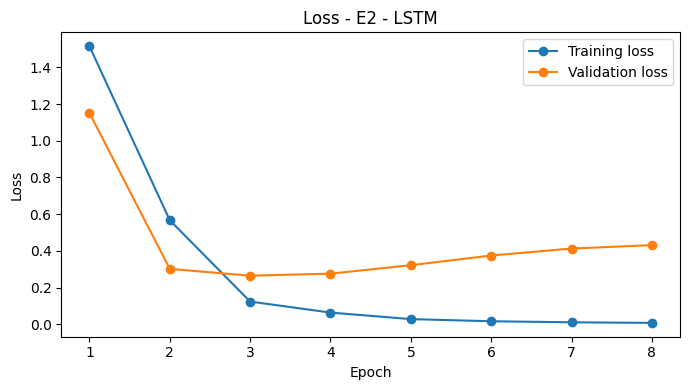

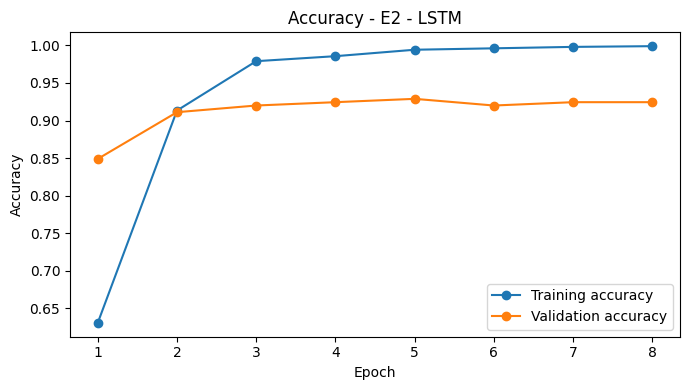

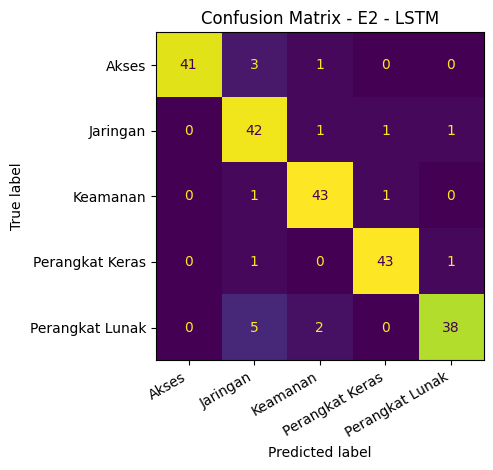

In [27]:

tampilkan_history(
    history_e2,
    "E2 - LSTM",
)

tampilkan_confusion_matrix(
    "E2 - LSTM"
)


## 17. E3 — LSTM + Dropout 0,5

In [28]:

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

model_e3 = buat_model_lstm(
    dropout_rate=0.5,
    nama_model="E3_LSTM_Dropout",
)

model_e3.summary()


Model: "E3_LSTM_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 19, 64)    │     36,480 │ sequence[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 19)        │          0 │ sequence[0][0]    │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     33,024 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,829 (272.77 KB)

 Trainable params: 69,829 (272.77 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:

history_e3 = model_e3.fit(
    X_train_seq,
    y_train.to_numpy(),
    validation_data=(
        X_val_seq,
        y_val.to_numpy(),
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        buat_early_stopping()
    ],
    verbose=1,
)

history_model["E3 - LSTM + Dropout"] = history_e3

simpan_ringkasan_history(
    "E3 - LSTM + Dropout",
    history_e3,
)

pred_e3 = np.argmax(
    model_e3.predict(
        X_test_seq,
        batch_size=BATCH_SIZE,
        verbose=0,
    ),
    axis=1,
)

evaluasi_model(
    "E3 - LSTM + Dropout",
    y_test,
    pred_e3,
)


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6076 - loss: 1.5425 - val_accuracy: 0.8622 - val_loss: 1.2950
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8914 - loss: 0.6253 - val_accuracy: 0.8933 - val_loss: 0.3057
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9752 - loss: 0.1399 - val_accuracy: 0.9333 - val_loss: 0.2690
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9848 - loss: 0.0711 - val_accuracy: 0.9378 - val_loss: 0.3046
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9943 - loss: 0.0408 - val_accuracy: 0.9200 - val_loss: 0.3273
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9971 - loss: 0.0255 - val_accuracy: 0.9244 - val_loss: 0.3472
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0164 - val_accuracy: 0.9289 - val_loss: 0.3808
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9990 - loss: 0.0108 - val_accuracy: 0.9378 - val_l

2026-08-16 13:09:32.841840: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


E3 - LSTM + Dropout
-------------------
Accuracy        : 0.9156
Macro Precision : 0.9218
Macro Recall    : 0.9156
Macro F1        : 0.9165


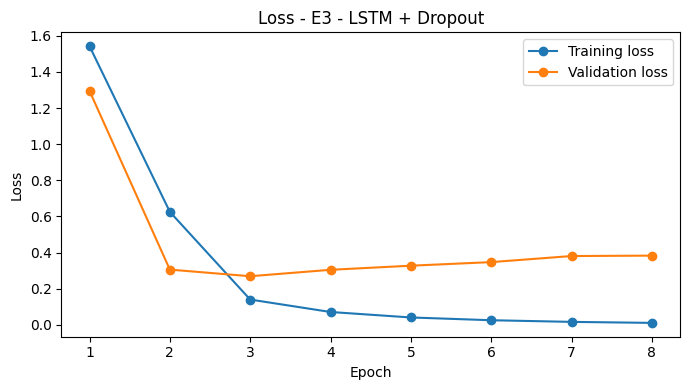

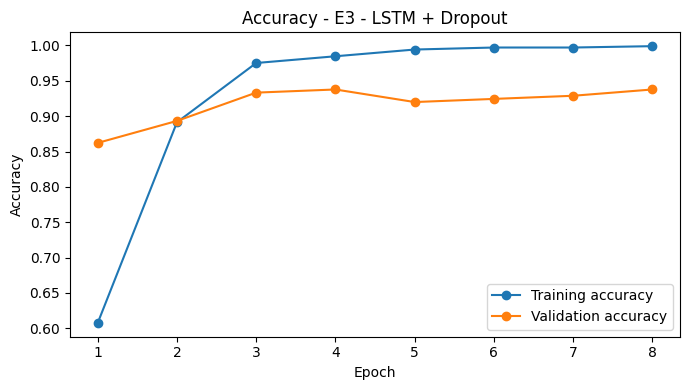

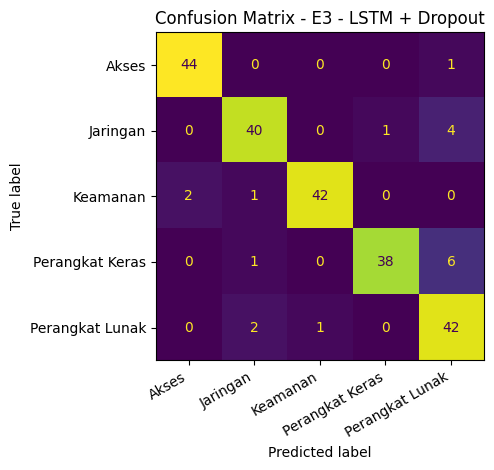

In [30]:

tampilkan_history(
    history_e3,
    "E3 - LSTM + Dropout",
)

tampilkan_confusion_matrix(
    "E3 - LSTM + Dropout"
)


## 18. Perbandingan hasil seluruh model

In [31]:

hasil_df = (
    pd.DataFrame(hasil_model)
    .drop_duplicates(
        subset=["Model"],
        keep="last",
    )
    .sort_values(
        "Macro F1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    hasil_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
    })
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,E1 - MLP,0.9511,0.9523,0.9511,0.9509
1,B0 - Logistic Regression,0.9422,0.9435,0.9422,0.9423
2,E2 - LSTM,0.9200,0.9256,0.9200,0.9208
3,E3 - LSTM + Dropout,0.9156,0.9218,0.9156,0.9165


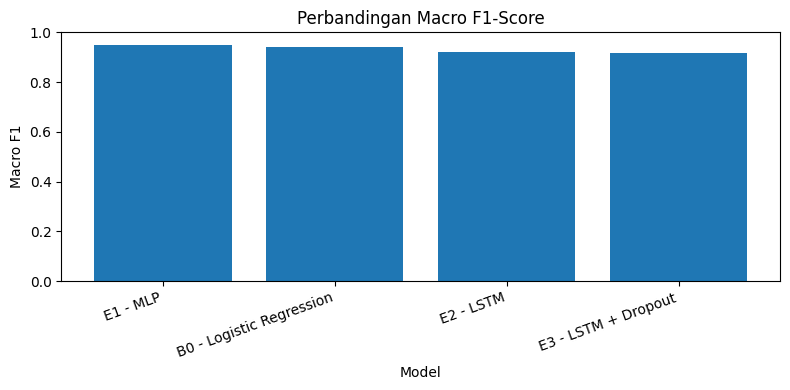

In [32]:

plt.figure(figsize=(8, 4))

plt.bar(
    hasil_df["Model"],
    hasil_df["Macro F1"],
)

plt.title("Perbandingan Macro F1-Score")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(
    rotation=20,
    ha="right",
)
plt.tight_layout()
plt.show()


## 19. Ringkasan proses training deep learning

In [33]:

training_df = (
    pd.DataFrame(ringkasan_training)
    .sort_values("Model")
    .reset_index(drop=True)
)

display(
    training_df.style.format({
        "Train Accuracy @ Best": "{:.4f}",
        "Validation Accuracy @ Best": "{:.4f}",
        "Minimum Validation Loss": "{:.4f}",
        "Gap Accuracy @ Best": "{:.4f}",
    })
)


,Model,Epoch Dijalankan,Epoch Terbaik,Train Accuracy @ Best,Validation Accuracy @ Best,Minimum Validation Loss,Gap Accuracy @ Best
0,E1 - MLP,12,8,1.0000,0.9689,0.1388,0.0311
1,E2 - LSTM,8,3,0.9790,0.9200,0.2654,0.0590
2,E3 - LSTM + Dropout,8,3,0.9752,0.9333,0.2690,0.0419



## 20. Analisis tambahan: before–after augmentasi

Biar perbandingannya fair, saya pakai test set yang sama untuk kondisi sebelum dan sesudah augmentasi. Jadi kalau performanya berubah, kita bisa lebih yakin perubahan itu memang karena augmentasi datanya..

- Test set berasal dari tiket dataset awal pada Subkategori yang sudah ditetapkan sebagai grup testing.
- Kondisi **sebelum augmentasi** hanya menggunakan data awal pada grup training.
- Kondisi **setelah augmentasi** menggunakan data final pada grup training.
- Tidak ada Subkategori testing yang masuk ke training pada kedua kondisi.

Perbandingan dilakukan pada B0 dan E1.


In [34]:

awal_train_df = (
    df_awal_bersih[
        df_awal_bersih["Subkategori"].isin(group_train)
    ]
    .reset_index(drop=True)
)

awal_val_df = (
    df_awal_bersih[
        df_awal_bersih["Subkategori"].isin(group_val)
    ]
    .reset_index(drop=True)
)

print("Data awal - train      :", len(awal_train_df))
print("Data awal - validation :", len(awal_val_df))
print("Common test set        :", len(common_test_df))
print("Data augmented - train :", len(train_df))

display(
    common_test_df["Kategori"]
    .value_counts()
    .reindex(KELAS)
    .rename("Common Test")
    .to_frame()
)


Data awal - train      : 343
Data awal - validation : 75
Common test set        : 75
Data augmented - train : 1050


,Common Test
Kategori,
Akses,15
Jaringan,15
Keamanan,15
Perangkat Keras,15
Perangkat Lunak,15


In [35]:

pipeline_b0_awal = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=MAX_FEATURES_TFIDF,
            sublinear_tf=True,
        ),
    ),
    (
        "classifier",
        LogisticRegression(
            solver="lbfgs",
            max_iter=1000,
            random_state=SEED,
        ),
    ),
])

y_awal_train = (
    awal_train_df["Kategori"]
    .map(LABEL_TO_ID)
    .astype(int)
)

pipeline_b0_awal.fit(
    awal_train_df["Deskripsi_Bersih"],
    y_awal_train,
)

pred_b0_before = pipeline_b0_awal.predict(
    common_test_df["Deskripsi_Bersih"]
)

pred_b0_after = pred_b0_after_common

metrik_b0_before = hitung_metrik(
    y_common_test,
    pred_b0_before,
)

metrik_b0_after = hitung_metrik(
    y_common_test,
    pred_b0_after,
)


In [36]:

tfidf_awal = pipeline_b0_awal.named_steps["tfidf"]

X_awal_train_tfidf = (
    tfidf_awal
    .transform(awal_train_df["Deskripsi_Bersih"])
    .toarray()
    .astype("float32")
)

X_awal_val_tfidf = (
    tfidf_awal
    .transform(awal_val_df["Deskripsi_Bersih"])
    .toarray()
    .astype("float32")
)

X_common_before_tfidf = (
    tfidf_awal
    .transform(common_test_df["Deskripsi_Bersih"])
    .toarray()
    .astype("float32")
)

y_awal_val = (
    awal_val_df["Kategori"]
    .map(LABEL_TO_ID)
    .astype(int)
)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

model_e1_awal = buat_model_mlp(
    input_dim=X_awal_train_tfidf.shape[1],
    nama_model="E1_MLP_Before_Augmentation",
)

history_e1_awal = model_e1_awal.fit(
    X_awal_train_tfidf,
    y_awal_train.to_numpy(),
    validation_data=(
        X_awal_val_tfidf,
        y_awal_val.to_numpy(),
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        buat_early_stopping()
    ],
    verbose=1,
)

pred_e1_before = np.argmax(
    model_e1_awal.predict(
        X_common_before_tfidf,
        verbose=0,
    ),
    axis=1,
)

pred_e1_after = pred_e1_after_common


metrik_e1_before = hitung_metrik(
    y_common_test,
    pred_e1_before,
)

metrik_e1_after = hitung_metrik(
    y_common_test,
    pred_e1_after,
)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3907 - loss: 1.5841 - val_accuracy: 0.6000 - val_loss: 1.5390
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7143 - loss: 1.4994 - val_accuracy: 0.7600 - val_loss: 1.4499
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8163 - loss: 1.3835 - val_accuracy: 0.7600 - val_loss: 1.3124
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8571 - loss: 1.2077 - val_accuracy: 0.7467 - val_loss: 1.1109
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8892 - loss: 0.9759 - val_accuracy: 0.7600 - val_loss: 0.8855
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9038 - loss: 0.7341 - val_accuracy: 0.7867 - val_loss: 0.7012
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9242 - loss: 0.5341 - val_accuracy: 0.7733 - val_loss: 0.5881
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9329 - loss: 0.3939 - val_accuracy: 0.7867 - v

2026-08-16 13:09:38.148910: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [37]:

hasil_augmentasi = pd.DataFrame([
    {
        "Model": "B0 - Logistic Regression",
        "Kondisi": "Sebelum Augmentasi",
        "Jumlah Training": len(awal_train_df),
        **metrik_b0_before,
    },
    {
        "Model": "B0 - Logistic Regression",
        "Kondisi": "Setelah Augmentasi",
        "Jumlah Training": len(train_df),
        **metrik_b0_after,
    },
    {
        "Model": "E1 - MLP",
        "Kondisi": "Sebelum Augmentasi",
        "Jumlah Training": len(awal_train_df),
        **metrik_e1_before,
    },
    {
        "Model": "E1 - MLP",
        "Kondisi": "Setelah Augmentasi",
        "Jumlah Training": len(train_df),
        **metrik_e1_after,
    },
])

display(
    hasil_augmentasi.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
    })
)


,Model,Kondisi,Jumlah Training,Accuracy,Macro Precision,Macro Recall,Macro F1
0,B0 - Logistic Regression,Sebelum Augmentasi,343,0.8267,0.8391,0.8267,0.8266
1,B0 - Logistic Regression,Setelah Augmentasi,1050,0.8267,0.8376,0.8267,0.8267
2,E1 - MLP,Sebelum Augmentasi,343,0.8533,0.8538,0.8533,0.8528
3,E1 - MLP,Setelah Augmentasi,1050,0.8533,0.8617,0.8533,0.8506


## 21. Error analysis model terbaik

In [38]:

model_terbaik = hasil_df.iloc[0]["Model"]
pred_terbaik = prediksi_model[model_terbaik]

error_df = test_df[
    [
        "Kategori",
        "Subkategori",
        "Deskripsi",
        "Deskripsi_Bersih",
        "Asal_Data",
    ]
].copy()

error_df["Prediksi"] = [
    ID_TO_LABEL[int(i)]
    for i in pred_terbaik
]

error_df["Benar"] = (
    error_df["Kategori"]
    == error_df["Prediksi"]
)

salah_df = (
    error_df[
        ~error_df["Benar"]
    ]
    .reset_index(drop=True)
)

print("Model terbaik         :", model_terbaik)
print("Jumlah test           :", len(test_df))
print("Prediksi salah        :", len(salah_df))
print(
    "Error rate            :",
    f"{len(salah_df)/len(test_df):.2%}"
)

if len(salah_df) > 0:
    display(
        salah_df[
            [
                "Deskripsi",
                "Subkategori",
                "Kategori",
                "Prediksi",
                "Asal_Data",
            ]
        ].head(25)
    )
else:
    print(
        "Tidak ada kesalahan pada test set. "
        "Hasil tetap perlu dibahas dengan mempertimbangkan sifat dataset sintetis."
    )


Model terbaik         : E1 - MLP
Jumlah test           : 225
Prediksi salah        : 11
Error rate            : 4.89%


,Deskripsi,Subkategori,Kategori,Prediksi,Asal_Data
0,Pengguna melaporkan sesi berakhir karena batas...,Sesi berakhir karena batas waktu,Perangkat Lunak,Akses,Dataset awal
1,Pengguna melaporkan masalah resolusi dns. Dipe...,Masalah resolusi DNS,Jaringan,Perangkat Keras,Dataset awal
2,Pengguna melaporkan sertifikat kedaluwarsa. Di...,Sertifikat kedaluwarsa,Keamanan,Akses,Dataset awal
3,Pengguna melaporkan masalah captive portal. Di...,Masalah captive portal,Jaringan,Perangkat Keras,Dataset awal
4,Pengguna melaporkan hotspot tidak berfungsi. D...,Hotspot tidak berfungsi,Jaringan,Perangkat Keras,Dataset awal
5,Pengguna melaporkan permintaan hak administrat...,Permintaan hak administrator,Akses,Keamanan,Dataset awal
6,Pengguna melaporkan layanan tidak dapat dimula...,Layanan tidak dapat dimulai,Perangkat Lunak,Jaringan,Dataset awal
7,Pengguna melaporkan kekuatan sinyal lemah. Dip...,Kekuatan sinyal lemah,Jaringan,Keamanan,Dataset awal
8,Pengguna melaporkan lonjakan latensi. Diperluk...,Lonjakan latensi,Jaringan,Keamanan,Dataset awal
9,Pengguna melaporkan kebocoran memori terdeteks...,Kebocoran memori terdeteksi,Perangkat Lunak,Keamanan,Dataset awal


In [39]:

if len(salah_df) > 0:
    pasangan_error = (
        salah_df
        .groupby(
            ["Kategori", "Prediksi"]
        )
        .size()
        .reset_index(name="Jumlah")
        .sort_values(
            "Jumlah",
            ascending=False,
        )
    )

    display(pasangan_error)


,Kategori,Prediksi,Jumlah
2,Jaringan,Perangkat Keras,3
1,Jaringan,Keamanan,2
0,Akses,Keamanan,1
3,Keamanan,Akses,1
4,Perangkat Keras,Perangkat Lunak,1
5,Perangkat Lunak,Akses,1
6,Perangkat Lunak,Jaringan,1
7,Perangkat Lunak,Keamanan,1


## 22. Classification report model terbaik

In [40]:

print(
    classification_report(
        y_test,
        pred_terbaik,
        labels=range(len(KELAS)),
        target_names=KELAS,
        zero_division=0,
    )
)

report_terbaik = pd.DataFrame(
    classification_report(
        y_test,
        pred_terbaik,
        labels=range(len(KELAS)),
        target_names=KELAS,
        zero_division=0,
        output_dict=True,
    )
).T

display(report_terbaik)


                 precision    recall  f1-score   support

          Akses       0.96      0.98      0.97        45
       Jaringan       0.98      0.89      0.93        45
       Keamanan       0.92      0.98      0.95        45
Perangkat Keras       0.94      0.98      0.96        45
Perangkat Lunak       0.98      0.93      0.95        45

       accuracy                           0.95       225
      macro avg       0.95      0.95      0.95       225
   weighted avg       0.95      0.95      0.95       225



,precision,recall,f1-score,support
Akses,0.956522,0.977778,0.967033,45.000000
Jaringan,0.975610,0.888889,0.930233,45.000000
Keamanan,0.916667,0.977778,0.946237,45.000000
Perangkat Keras,0.936170,0.977778,0.956522,45.000000
Perangkat Lunak,0.976744,0.933333,0.954545,45.000000
accuracy,0.951111,0.951111,0.951111,0.951111
macro avg,0.952343,0.951111,0.950914,225.000000
weighted avg,0.952343,0.951111,0.950914,225.000000


## 23. Ringkasan angka untuk Results and Discussion

In [41]:

print("=" * 70)
print("RINGKASAN EKSPERIMEN FINAL")
print("=" * 70)

print("\nDATASET")
print(f"Data unik sebelum augmentasi : {len(df_awal_bersih)}")
print(f"Data tambahan sintetis       : {len(df_tambahan_bersih)}")
print(f"Data final                   : {len(df)}")
print(f"Training / Validation / Test : {len(train_df)} / {len(val_df)} / {len(test_df)}")
print("Overlap Subkategori          : 0")

print("\nHASIL MODEL UTAMA")
print(
    hasil_df[
        [
            "Model",
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nMODEL TERBAIK")
print("Model    :", model_terbaik)
print(
    "Macro F1 :",
    f"{hasil_df.iloc[0]['Macro F1']:.4f}"
)

print("\nBEFORE–AFTER AUGMENTASI")
print(
    hasil_augmentasi[
        [
            "Model",
            "Kondisi",
            "Jumlah Training",
            "Accuracy",
            "Macro F1",
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)

print("\nERROR ANALYSIS")
print("Jumlah salah prediksi :", len(salah_df))


RINGKASAN EKSPERIMEN FINAL

DATASET
Data unik sebelum augmentasi : 493
Data tambahan sintetis       : 1007
Data final                   : 1500
Training / Validation / Test : 1050 / 225 / 225
Overlap Subkategori          : 0

HASIL MODEL UTAMA
                   Model  Accuracy  Macro Precision  Macro Recall  Macro F1
                E1 - MLP    0.9511           0.9523        0.9511    0.9509
B0 - Logistic Regression    0.9422           0.9435        0.9422    0.9423
               E2 - LSTM    0.9200           0.9256        0.9200    0.9208
     E3 - LSTM + Dropout    0.9156           0.9218        0.9156    0.9165

MODEL TERBAIK
Model    : E1 - MLP
Macro F1 : 0.9509

BEFORE–AFTER AUGMENTASI
                   Model            Kondisi  Jumlah Training  Accuracy  Macro F1
B0 - Logistic Regression Sebelum Augmentasi              343    0.8267    0.8266
B0 - Logistic Regression Setelah Augmentasi             1050    0.8267    0.8267
                E1 - MLP Sebelum Augmentasi             

## 24. Menyimpan seluruh hasil eksperimen

In [42]:

FILE_HASIL_MODEL = (
    OUTPUT_DIR
    / "hasil_model_utama.csv"
)

FILE_TRAINING = (
    OUTPUT_DIR
    / "ringkasan_training_deep_learning.csv"
)

FILE_AUGMENTASI = (
    OUTPUT_DIR
    / "hasil_before_after_augmentasi.csv"
)

FILE_ERROR = (
    OUTPUT_DIR
    / "error_analysis_model_terbaik.csv"
)

FILE_REPORT = (
    OUTPUT_DIR
    / "classification_report_model_terbaik.csv"
)

hasil_df.to_csv(
    FILE_HASIL_MODEL,
    index=False,
    encoding="utf-8-sig",
)

training_df.to_csv(
    FILE_TRAINING,
    index=False,
    encoding="utf-8-sig",
)

hasil_augmentasi.to_csv(
    FILE_AUGMENTASI,
    index=False,
    encoding="utf-8-sig",
)

salah_df.to_csv(
    FILE_ERROR,
    index=False,
    encoding="utf-8-sig",
)

report_terbaik.to_csv(
    FILE_REPORT,
    encoding="utf-8-sig",
)

for nama_model, history in history_model.items():
    nama_file = (
        nama_model
        .lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("-", "")
    )

    pd.DataFrame(
        history.history
    ).to_csv(
        OUTPUT_DIR
        / f"history_{nama_file}.csv",
        index=False,
        encoding="utf-8-sig",
    )

print("Semua output tersimpan di:")
print(OUTPUT_DIR)


Semua output tersimpan di:
/kaggle/working/final_project_outputs
